In [1]:
import scanpy as sc
import sys
sys.path.append(r"D:\Scunpair_Project\Diagonal-integration")
adata_RNA = sc.read_h5ad(r'.\Dataset\scRNA+scATAC BMMC_Multiome_p10\BMMC-multiome-p10-RNA-counts.h5ad')
adata_ATAC = sc.read_h5ad(r'.\Dataset\scRNA+scATAC BMMC_Multiome_p10\BMMC-multiome-p10-ATAC-gam.h5ad')

In [2]:
# 取交集基因并对齐
cm_genes = sorted(list(set(adata_ATAC.var_names) & set(adata_RNA.var_names)))
adata_RNA = adata_RNA[:, cm_genes]
adata_ATAC = adata_ATAC[:, cm_genes]

# 计算高变基因
sc.pp.highly_variable_genes(adata_RNA, flavor='seurat_v3', n_top_genes=1000)
sc.pp.highly_variable_genes(adata_ATAC, flavor='seurat_v3', n_top_genes=1000)

# 取共同的高变基因
shared_genes = adata_RNA.var_names[adata_RNA.var.highly_variable | adata_ATAC.var.highly_variable]
shared_genes = list(shared_genes)

adata_RNA = adata_RNA[:,shared_genes].copy()
adata_ATAC = adata_ATAC[:,shared_genes].copy()

sc.pp.normalize_total(adata_RNA)
sc.pp.log1p(adata_RNA)

sc.pp.normalize_total(adata_ATAC)
sc.pp.log1p(adata_ATAC)

c:\Users\Administrator\miniconda3\envs\mycode\lib\site-packages\scanpy\preprocessing\_highly_variable_genes.py:174: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns["hvg"] = {"flavor": flavor}
c:\Users\Administrator\miniconda3\envs\mycode\lib\site-packages\scanpy\preprocessing\_highly_variable_genes.py:174: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns["hvg"] = {"flavor": flavor}


In [3]:
import mycode
#mycode.utils.batch_scale(adata_RNA,method='standard')
#mycode.utils.batch_scale(adata_ATAC,method='standard')
sc.pp.scale(adata_RNA, max_value=10)
sc.pp.scale(adata_ATAC, max_value=10)

c:\Users\Administrator\miniconda3\envs\mycode\lib\functools.py:889: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)
c:\Users\Administrator\miniconda3\envs\mycode\lib\functools.py:889: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


In [4]:
model = mycode.Model(adata_RNA, adata_ATAC, batch_size=500, 
                           training_steps=6000, seed=1234, celltype_col='cell_type',source_col='batch',
                            n_latent=16, lambdaRecon = 10.0, lambdaLA = 10.0, 
                            lambdaOT = 1.0, lambdamGAN = 1.0, lambdabGAN = 1.0, n_KNN = 30, lambdaGeo=0.05, mode = 'strong', use_prior = False)

In [5]:
model.train()

Training started at: Sat Aug 30 10:35:50 2025
Step 0 | Recon: 21.7888 | LA: 50.5094 | OT: 16.3391 | Geo: 20.1347 | mGAN: -1.3727 | bGAN: -5.2049
Step 1000 | Recon: 16.1563 | LA: 0.0262 | OT: 0.1026 | Geo: 0.2528 | mGAN: -1.3600 | bGAN: -4.8687
Step 2000 | Recon: 16.2339 | LA: 0.0182 | OT: 0.0857 | Geo: 0.2023 | mGAN: -1.3877 | bGAN: -4.9044
Step 3000 | Recon: 15.9738 | LA: 0.0358 | OT: 0.1182 | Geo: 0.2745 | mGAN: -1.3824 | bGAN: -4.8533
Step 4000 | Recon: 15.8041 | LA: 0.0227 | OT: 0.1015 | Geo: 0.2167 | mGAN: -1.3862 | bGAN: -4.8962
Step 5000 | Recon: 15.8154 | LA: 0.0261 | OT: 0.0970 | Geo: 0.2006 | mGAN: -1.3915 | bGAN: -4.8400
Training finished. Time: 250.99 sec


In [6]:
model.eval()

Evaluation started at: Sat Aug 30 10:40:01 2025
Evaluation completed at: Sat Aug 30 10:40:01 2025
Total evaluation time: 0.10 seconds
Processed 13848 samples
Latent space shape: (13848, 16)


In [7]:
import anndata as ad
import pandas as pd
adata_integrated = ad.AnnData(X=model.latent)
adata_integrated.obs = pd.concat([adata_RNA.obs, adata_ATAC.obs])
adata_integrated.obs['modality'] = ['RNA'] * adata_RNA.shape[0] + ['ATAC'] * adata_ATAC.shape[0]

In [8]:
sc.pp.neighbors(adata_integrated)
sc.tl.umap(adata_integrated, min_dist=0.3)

c:\Users\Administrator\miniconda3\envs\mycode\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


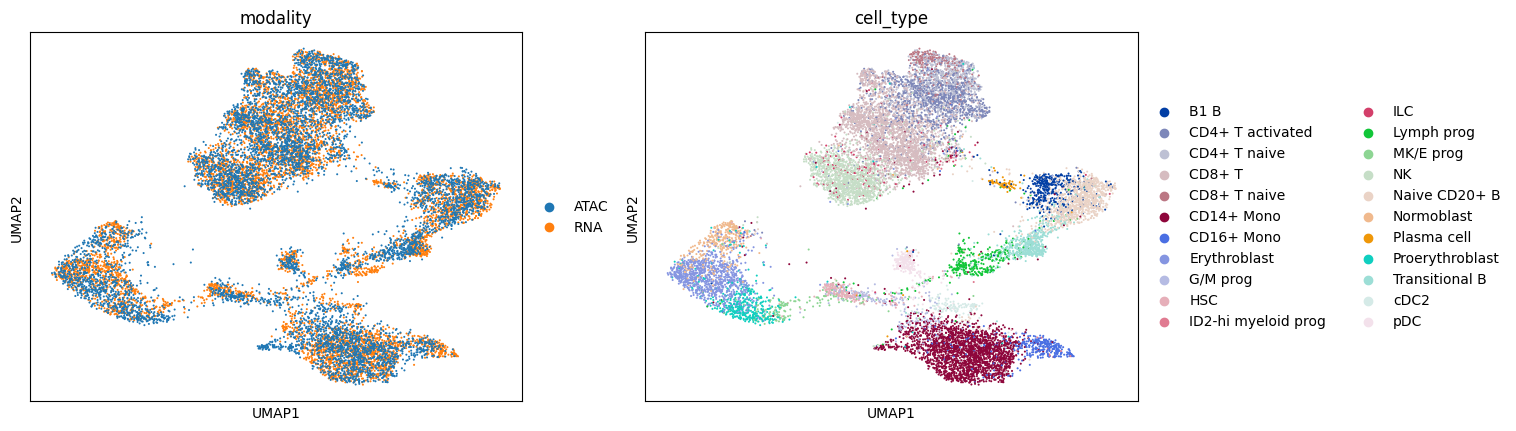

In [9]:
sc.pl.umap(adata_integrated, color=['modality','cell_type'])

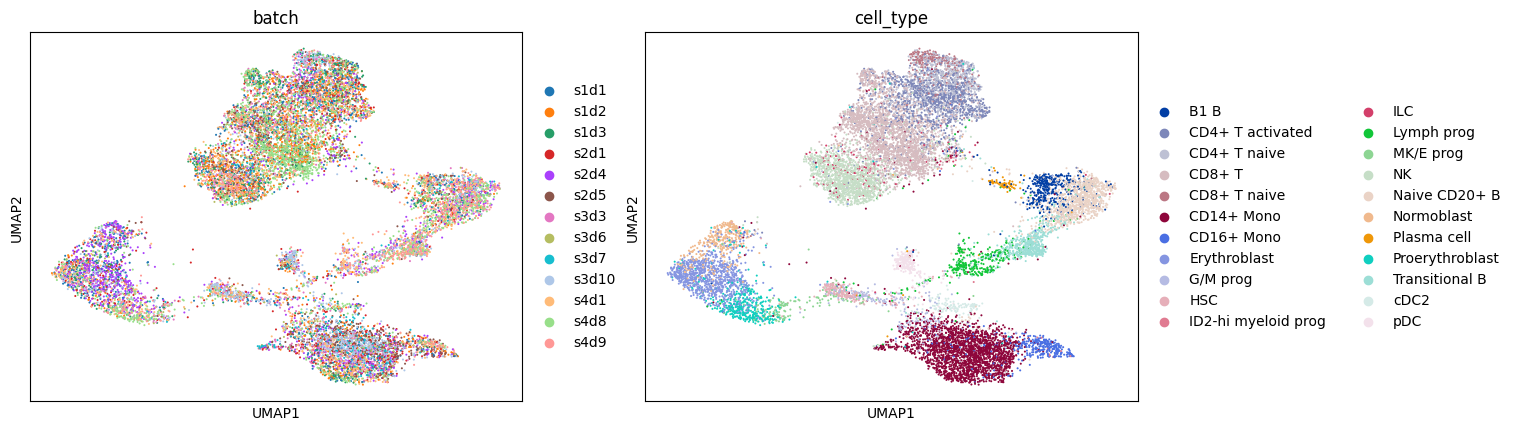

In [10]:
sc.pl.umap(adata_integrated, color=['batch','cell_type'])

In [11]:
model.latent[:adata_RNA.shape[0],:].shape

(6924, 16)

In [14]:
from scmmib.metrics import paired_graph_metrics,  mosaic_latent_metrics,\
    unpaired_latent_metrics
import numpy as np
import pandas as pd
import scanpy as sc
import anndata as ad

latent_atac = model.latent[adata_RNA.shape[0]:,:]
latent_rna = model.latent[:adata_RNA.shape[0],:]
meta = adata_RNA.obs
# 2. generate the ann data format and calculate the metrics
adata_unpaired = sc.AnnData(latent_rna, obs=meta, dtype='float32')
adata_unpaired.obsm['RNA'] = latent_rna
adata_unpaired.obsm['ATAC'] = latent_atac
out = unpaired_latent_metrics(adata_unpaired, method = "bindSC", cluster = 'louvain', batch = None, label = 'cell_type', mods = ["RNA","ATAC"], outf=None, embed_acc=True) # outf=None,return stdout, or return the path or "outf" param, for example, outf="./test.txt"

ModuleNotFoundError: No module named 'scmmib'